In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')
from scipy import stats

In [3]:
df =pd.read_csv('clean_dataset.csv')
display(df.head())

,country,year,region,economic_tier,happiness_rank,global_hunger_rank,human_development_rank,gdp_per_capita_rank,life_expectancy_rank,corruption_perception_rank,democracy_rank,gini_rank,press_freedom_rank,global_peace_rank,environmental_performance_rank
0,Afghanistan,2000,Asia,low,195,208,187,212,186,185,215,183,214,216,212
1,Afghanistan,2001,Asia,low,198,207,188,215,186,185,215,180,214,217,214
2,Afghanistan,2002,Asia,low,196,208,192,213,185,185,215,174,214,217,213
3,Afghanistan,2003,Asia,low,196,207,195,214,183,185,215,173,214,217,214
4,Afghanistan,2004,Asia,low,194,210,197,214,183,185,216,172,214,217,212


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5859.0,2013.000000,7.789546,2000.0,2006.0,2013.0,2020.0,2026.0
happiness_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0
global_hunger_rank,5859.0,96.936849,75.533151,1.0,1.0,109.0,163.0,217.0
human_development_rank,5859.0,108.586790,62.031375,1.0,55.0,109.0,163.0,217.0
gdp_per_capita_rank,5859.0,108.971155,62.689388,1.0,55.0,109.0,163.0,217.0
life_expectancy_rank,5859.0,108.995904,62.649583,1.0,55.0,109.0,163.0,217.0
corruption_perception_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0
democracy_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0
gini_rank,5859.0,108.951528,62.672195,1.0,55.0,109.0,163.0,217.0
press_freedom_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0


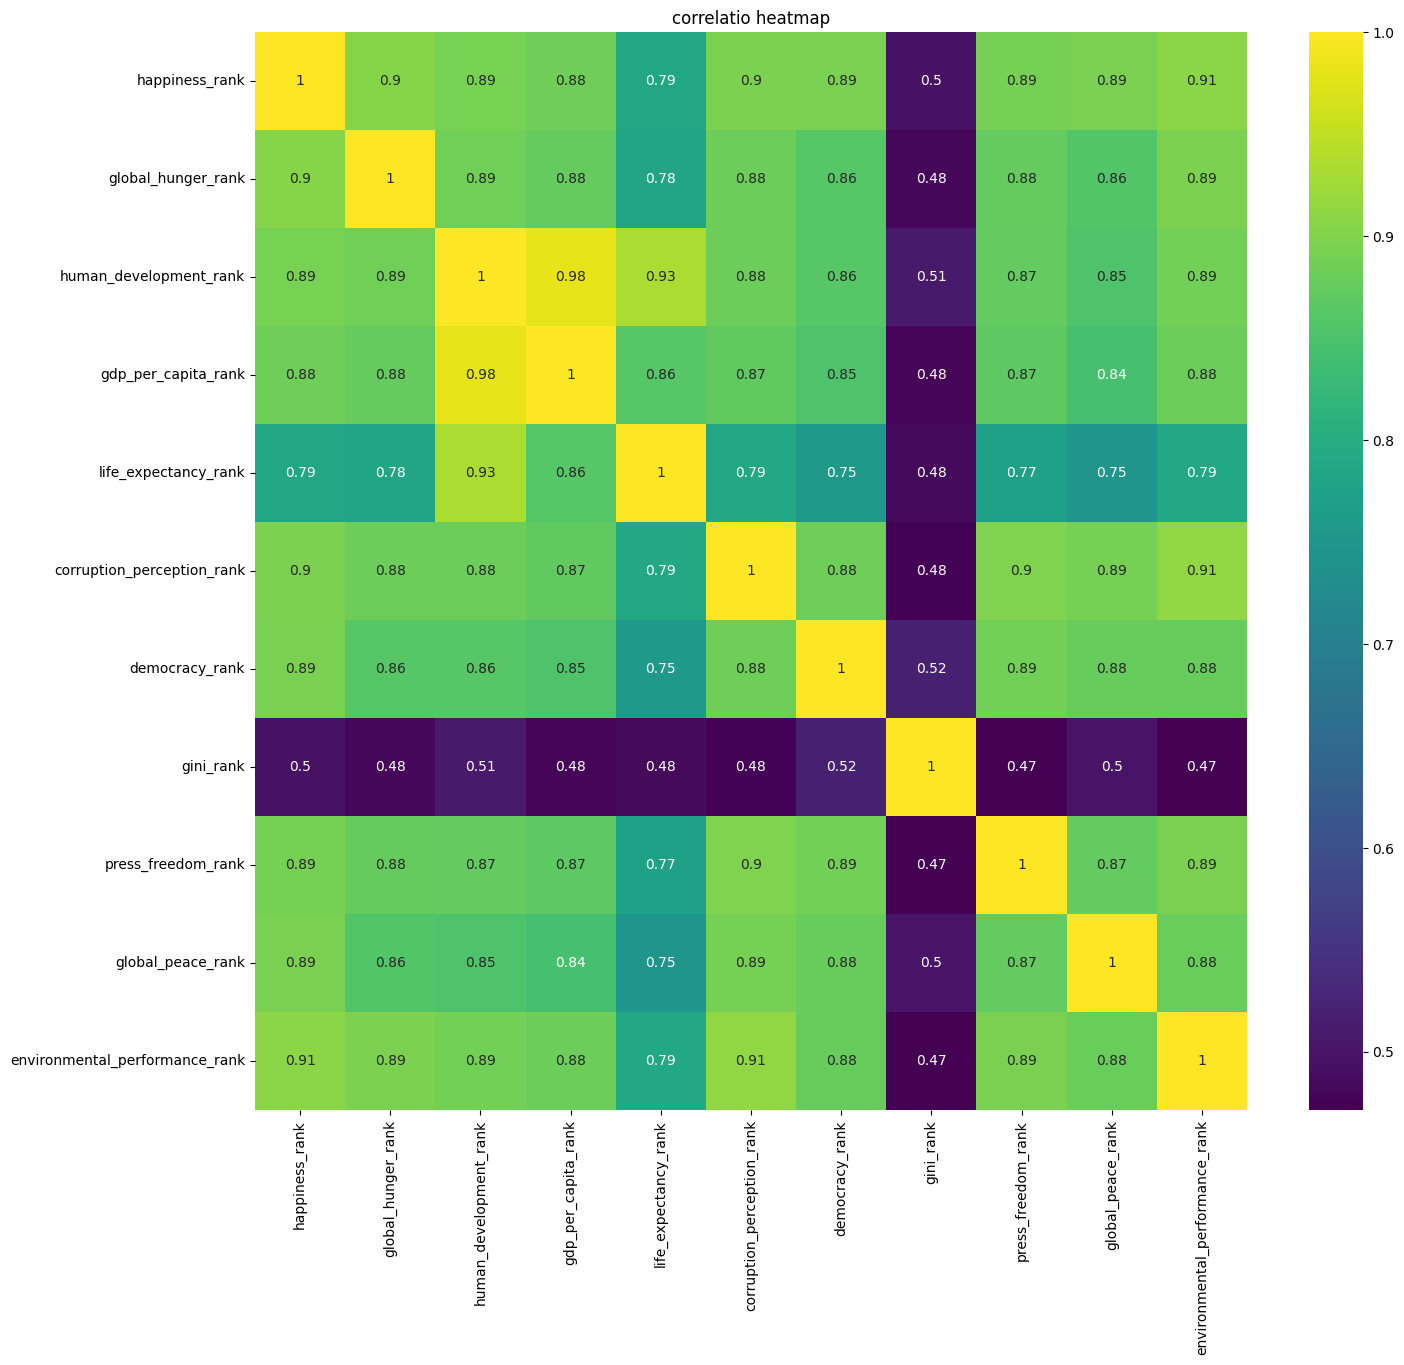

In [4]:
drop_col = df.drop(columns=['year'])
numeric_cols = drop_col.select_dtypes(include=['int64','float32','int32','float64'])
plt.figure(figsize=(16,14))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlatio heatmap")
plt.show()

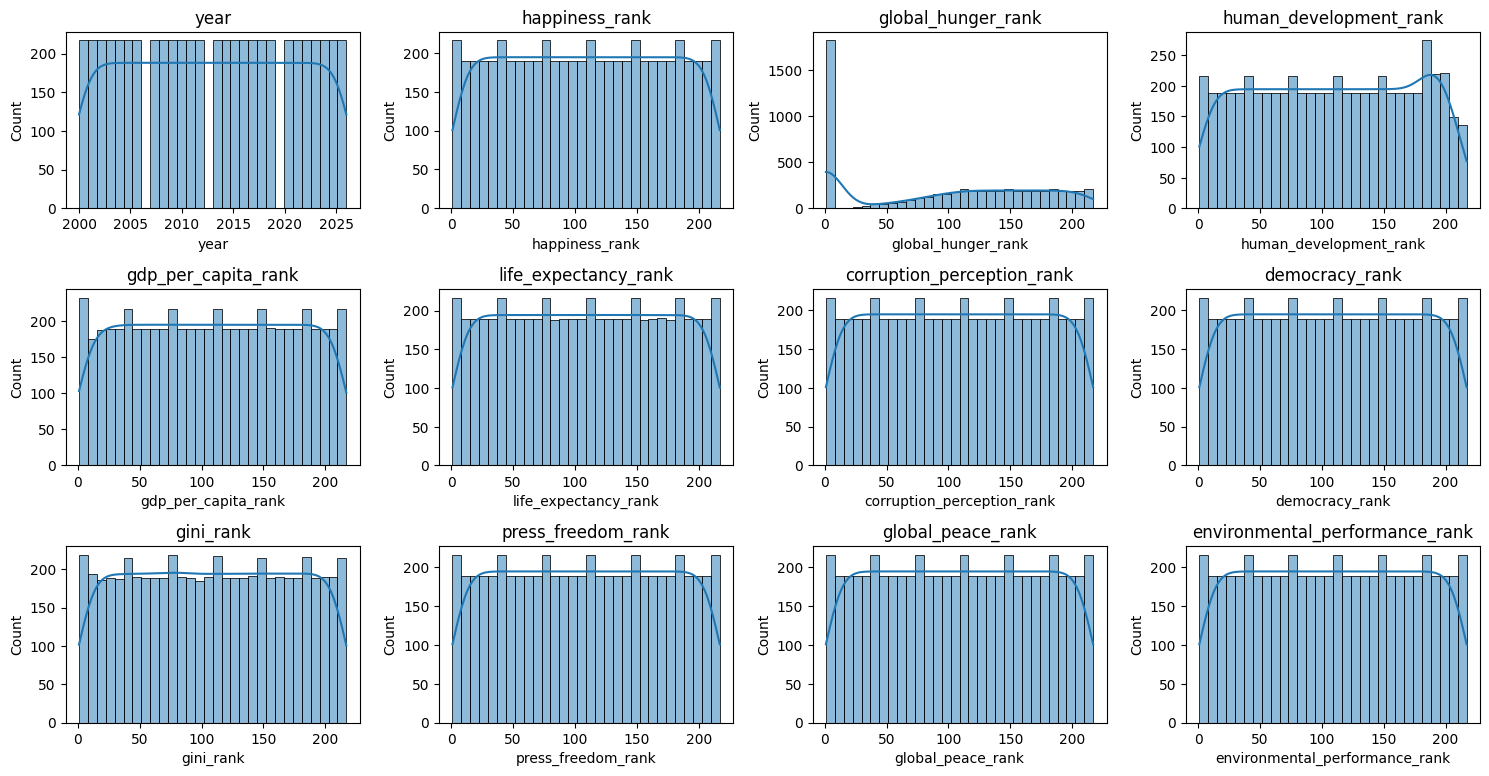

In [5]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

Human_Development_Rank vs GDP_Per_Capita_Rank

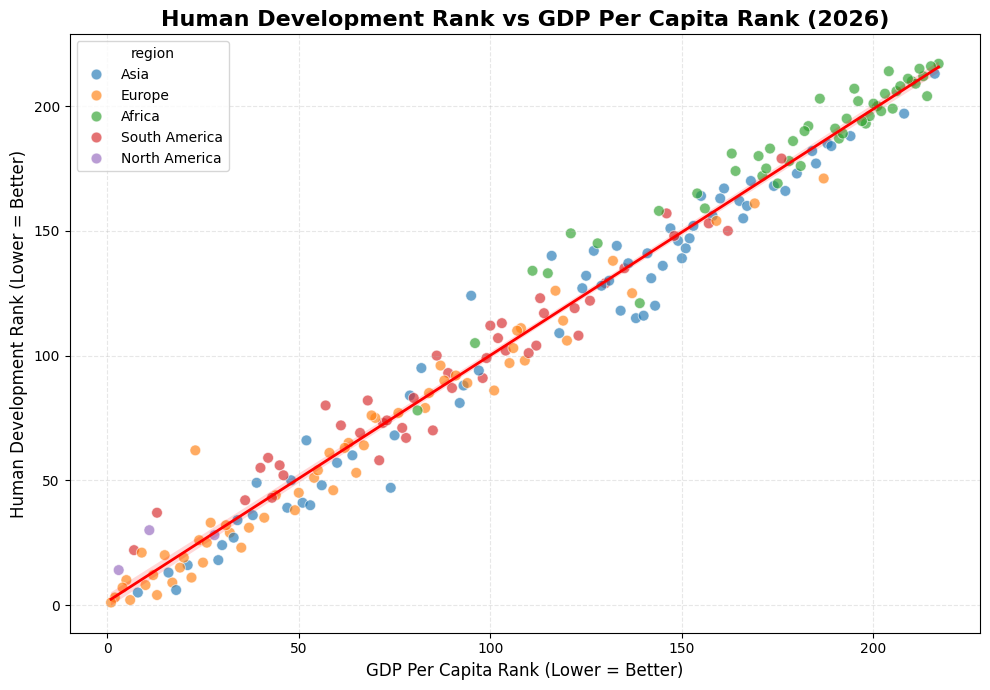

In [ ]:
df2026 = df[df['year'] == 2026].copy()
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df2026,
    x='gdp_per_capita_rank',
    y='human_development_rank',
    alpha=0.65,
    s=60,
    hue='region'
)

# Add regression line
sns.regplot(
    data=df2026,
    x='gdp_per_capita_rank',
    y='human_development_rank',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2}
)

plt.title("Human Development Rank vs GDP Per Capita Rank (2026)", fontsize=16, weight='bold')
plt.xlabel("GDP Per Capita Rank (Lower = Better)", fontsize=12)
plt.ylabel("Human Development Rank (Lower = Better)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

happiness_rank vs global_peace_rank

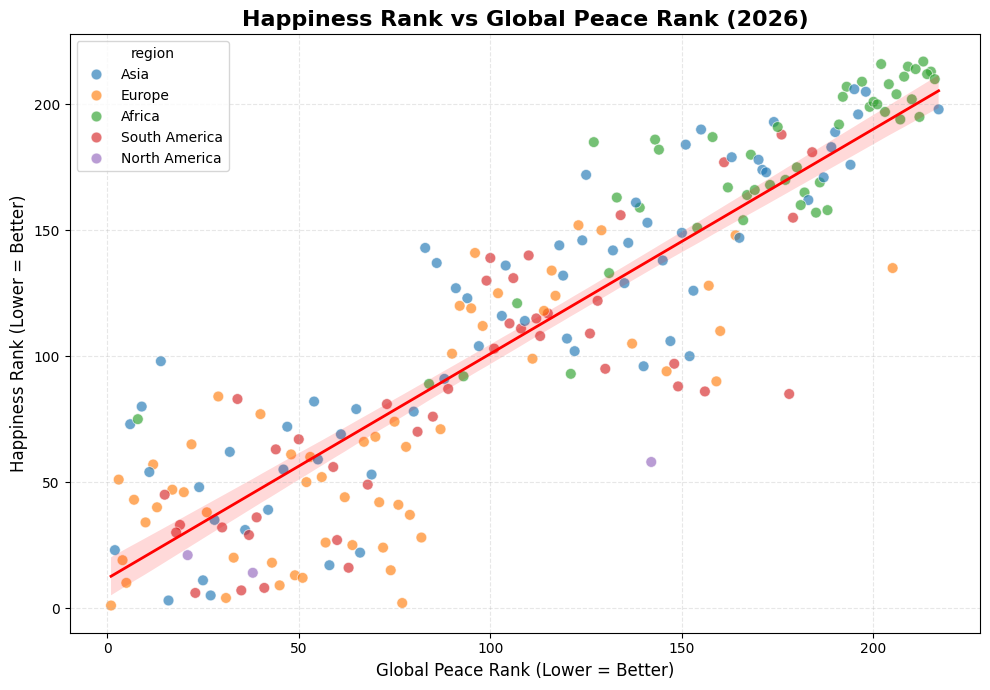

In [73]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df2026,
    x='global_peace_rank',
    y='happiness_rank',
    alpha=0.65,
    s=60,
    hue='region'
)

# Add regression line
sns.regplot(
    data=df2026,
    x='global_peace_rank',
    y='happiness_rank',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2}
)

plt.title("Happiness Rank vs Global Peace Rank (2026)", fontsize=16, weight='bold')
plt.xlabel("Global Peace Rank (Lower = Better)", fontsize=12)
plt.ylabel("Happiness Rank (Lower = Better)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
ranked_columns = ['happiness_rank', 'global_hunger_rank', 'gdp_per_capita_rank', 'human_development_rank', 'global_peace_rank' , 'life_expectancy_rank' , 'corruption_perception_rank' , 'democracy_rank' , 'gini_rank' , 'press_freedom_rank' ,'environmental_performance_rank']
df['composit_rank'] = df[ranked_columns].mean(axis=1).round(2) # lower ranke best perofrmance

top 10 best ranked country

,country,composit_rank
3995,Norway,5.00
3779,Netherlands,19.27
2051,Gibraltar,22.45
593,Bermuda,24.00
971,Canada,24.00
296,Australia,26.18
3185,"Macao SAR, China",26.18
5102,Switzerland,26.45
3104,Liechtenstein,27.36
1997,Germany,28.36


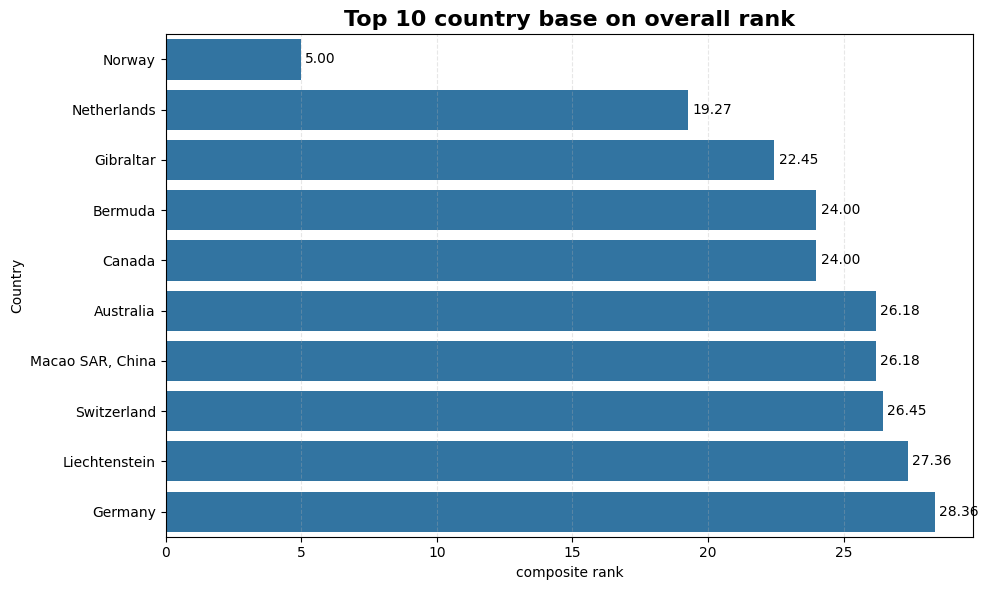

In [78]:
country_rank = df2026.nsmallest(10, 'composit_rank')[['country', 'composit_rank']]
display(country_rank)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=country_rank,
    x='composit_rank',
    y='country'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title("Top 10 country base on overall rank",
          fontsize=16, weight='bold')
plt.xlabel("composite rank")
plt.ylabel("Country")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

top 5 country most improved/declined over 27 years?

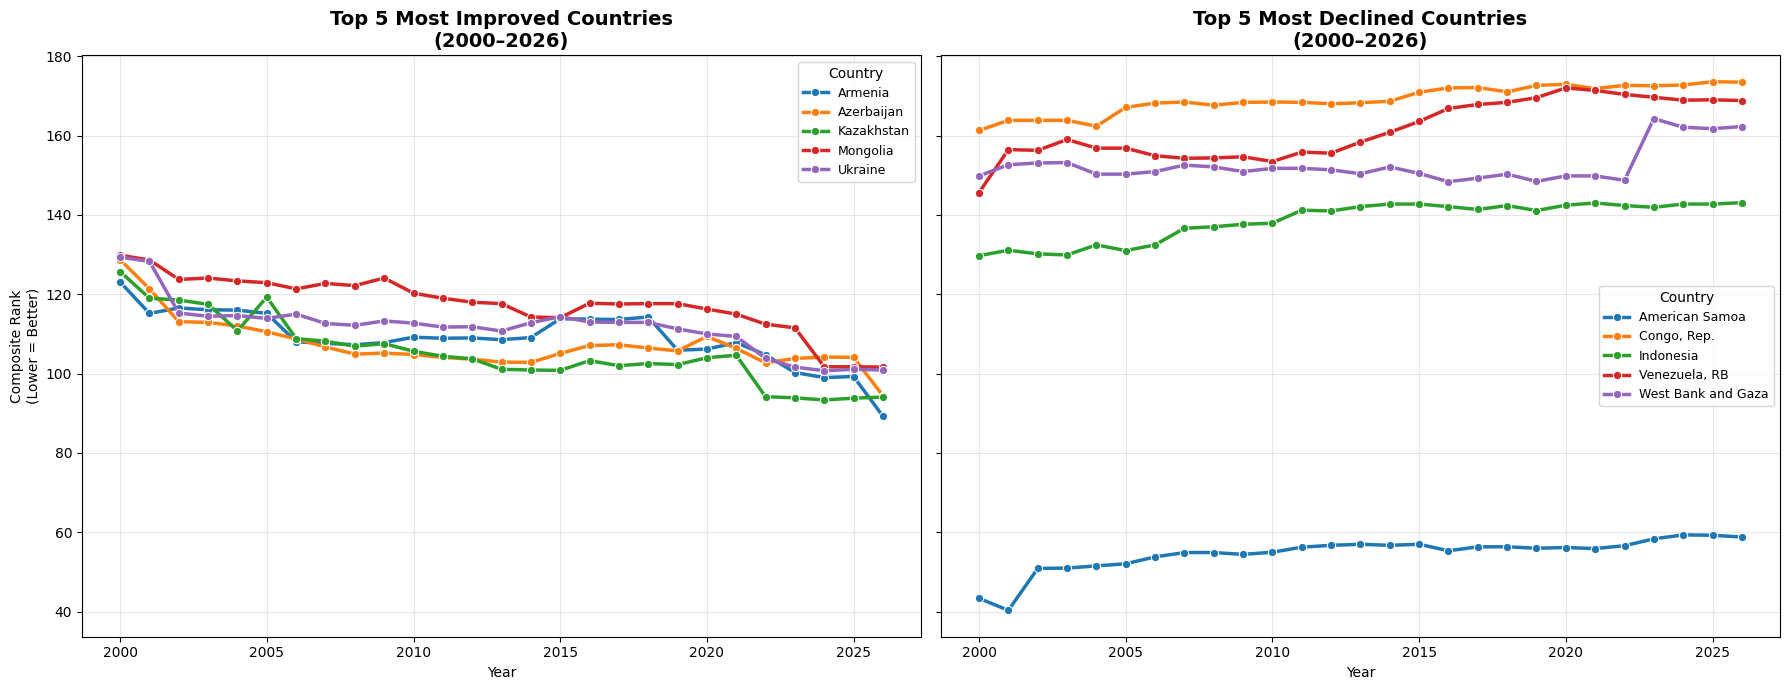

In [43]:
pivot = df.pivot(index='country', columns='year', values='composit_rank')

pivot['improvement'] = pivot[2000] - pivot[2026]
pivot['declined'] = pivot[2026] - pivot[2000]
top5_improved = (
    pivot.sort_values('improvement', ascending=False)
         .head(5)
         .index
)

top5_declined = (pivot.sort_values('declined', ascending=False)
         .head(5)
         .index)

improved_df = df[df['country'].isin(top5_improved)].sort_values(['country','year'])
declined_df = df[df['country'].isin(top5_declined)].sort_values(['country','year'])


fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# ---------------- improved ----------------
sns.lineplot(
    data=improved_df,
    x='year',
    y='composit_rank',
    hue='country',
    marker='o',
    linewidth=2.5,
    ax=axes[0]
)

axes[0].invert_yaxis()
axes[0].set_title(
    "Top 5 Most Improved Countries\n(2000–2026)",
    fontsize=14,
    weight='bold'
)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Composite Rank\n(Lower = Better)")
axes[0].grid(alpha=0.3)
axes[0].legend(title='Country', fontsize=9)

# ---------------- declined ----------------
sns.lineplot(
    data=declined_df,
    x='year',
    y='composit_rank',
    hue='country',
    marker='o',
    linewidth=2.5,
    ax=axes[1]
)

axes[1].invert_yaxis()
axes[1].set_title(
    "Top 5 Most Declined Countries\n(2000–2026)",
    fontsize=14,
    weight='bold'
)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("")
axes[1].grid(alpha=0.3)
axes[1].legend(title='Country', fontsize=9)

plt.tight_layout()
plt.show()

Composite score spread by Region & Economic Tier, 2000-2026

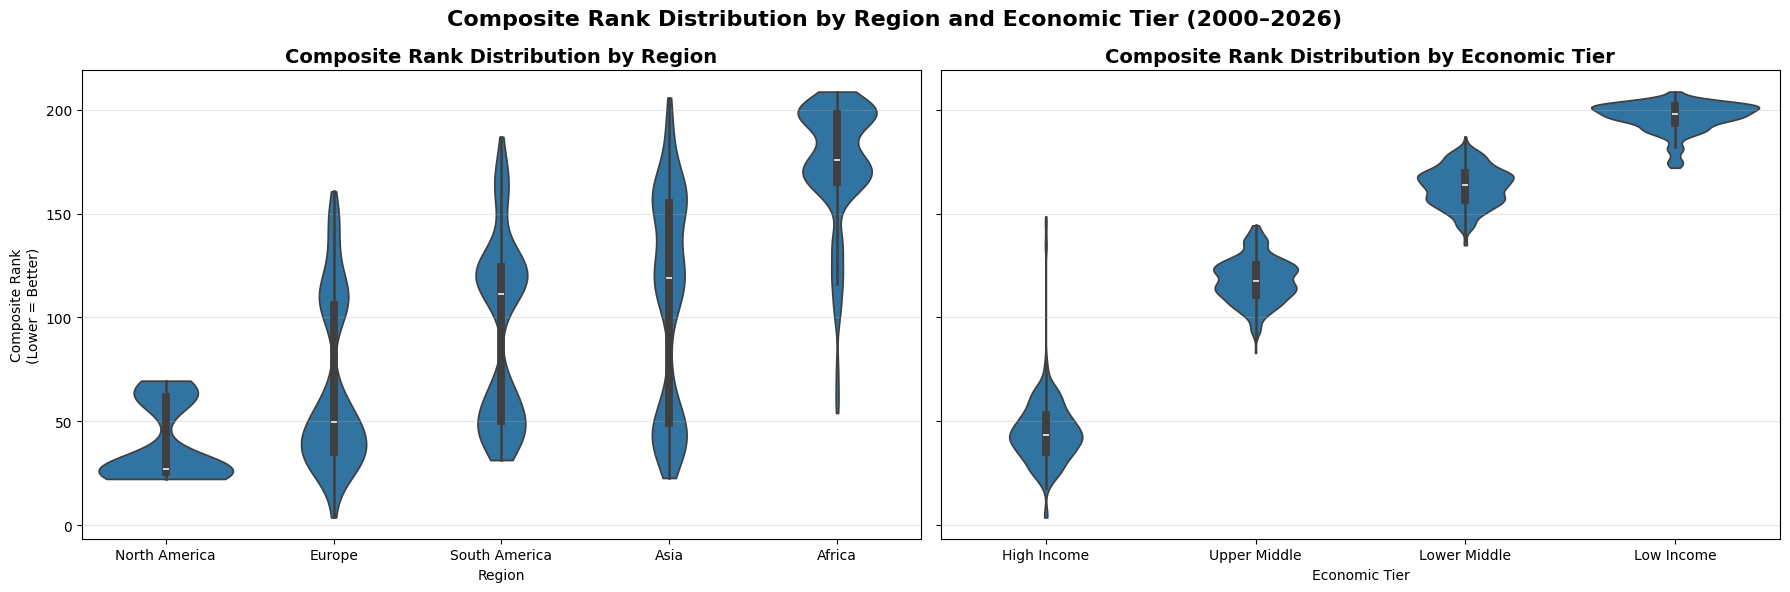

In [10]:
# Order Region by median composite rank
region_order = (
    df.groupby('region')['composit_rank']
      .median()
      .sort_values()
      .index
)

# Order Economic Tier by median composite rank
tier_order = (
    df.groupby('economic_tier')['composit_rank']
      .median()
      .sort_values()
      .index
)
fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)

# ---------- Region ----------
sns.violinplot(
    data=df,
    x='region',
    y='composit_rank',
    order=region_order,
    inner='box',
    cut=0,
    ax=axes[0]
)

axes[0].invert_yaxis()

axes[0].set_title(
    "Composite Rank Distribution by Region",
    fontsize=14,
    weight='bold'
)

axes[0].set_xlabel("Region")
axes[0].set_ylabel("Composite Rank\n(Lower = Better)")
axes[0].grid(axis='y', alpha=0.3)

# ---------- Economic Tier ----------
sns.violinplot(
    data=df,
    x='economic_tier',
    y='composit_rank',
    order=tier_order,
    inner='box',
    cut=0,
    ax=axes[1]
)

axes[1].invert_yaxis()

axes[1].set_title(
    "Composite Rank Distribution by Economic Tier",
    fontsize=14,
    weight='bold'
)

axes[1].set_xlabel("Economic Tier")
axes[1].set_ylabel("")
axes[1].grid(axis='y', alpha=0.3)

axes[1].set_xticklabels([
    "High Income",
    "Upper Middle",
    "Lower Middle",
    "Low Income"
])

plt.suptitle(
    "Composite Rank Distribution by Region and Economic Tier (2000–2026)",
    fontsize=16,
    weight='bold'
)

plt.tight_layout()
plt.show()

 Distribution shape of Composite Score, 2026

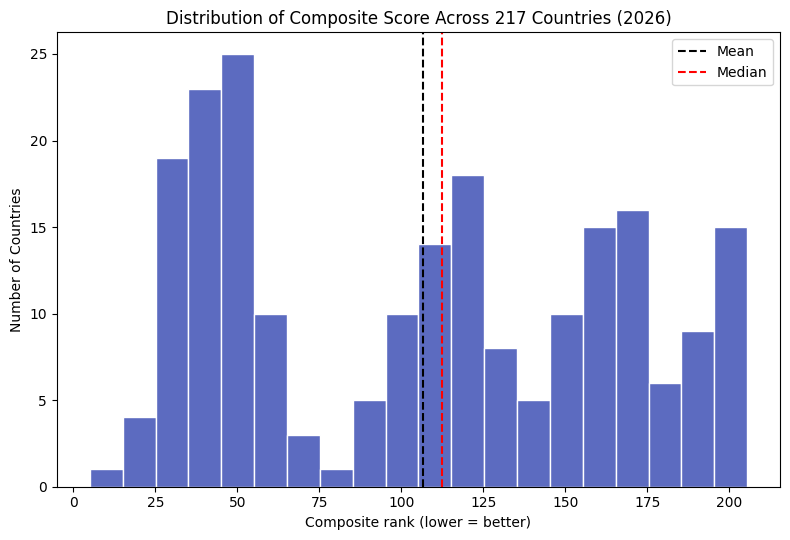

In [63]:
plt.figure(figsize=(8, 5.5))
plt.hist(df2026['composit_rank'], bins=20, color='#5c6bc0', edgecolor='white')
plt.axvline(df2026['composit_rank'].mean(), color='black', linestyle='--', label='Mean')
plt.axvline(df2026['composit_rank'].median(), color='red', linestyle='--', label='Median')
plt.title('Distribution of Composite Score Across 217 Countries (2026)')
plt.xlabel('Composite rank (lower = better)')
plt.ylabel('Number of Countries')
plt.legend()
plt.tight_layout()
plt.show()

Regional share of the Top 50 best-ranked countries, 2026

region
Europe           28
Asia             13
South America     7
North America     2
Name: count, dtype: int64

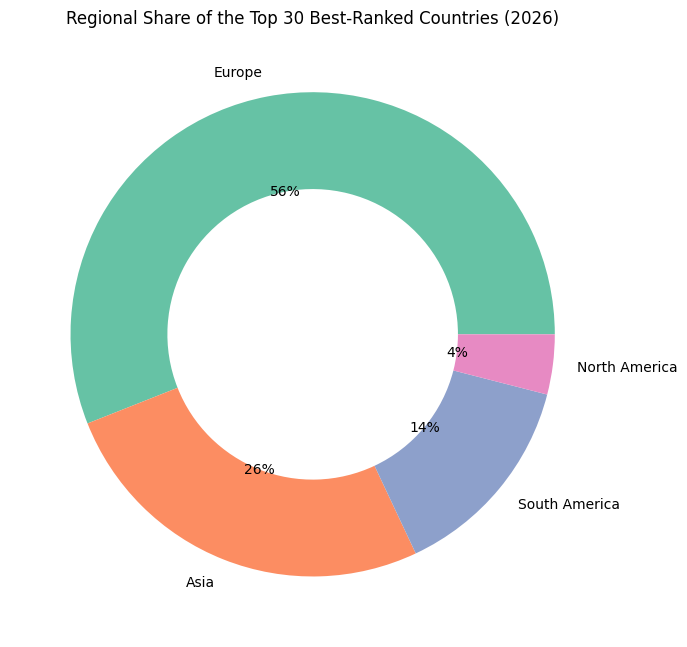

In [77]:
top30 = df2026.nsmallest(50, 'composit_rank')
region_share = top30['region'].value_counts()
display(region_share)
plt.figure(figsize=(7, 7))
plt.pie(region_share, labels=region_share.index, autopct='%1.0f%%',
        wedgeprops=dict(width=0.4), colors=sns.color_palette('Set2'))
plt.title('Regional Share of the Top 30 Best-Ranked Countries (2026)')
plt.tight_layout()
plt.show()